# Introduction



##### For any questions or inquiry, please email the authors: 

Floor Broekgaarden: fsbroekgaarden@gmail.com


This notebook loads gravitational-wave merger rate predictions from population synthesis models and visualizes them in a three-panel figure. The left panel shows key simulation properties (e.g. code, tracks, labels), the middle panel displays the relative fractions of different formation channels as stacked bars (e.g. \( f_{\mathrm{CE}} \), \( f_{\mathrm{OSMT}} \)), and the right panel plots both the total predicted merger rates \( \mathcal{R}_{\mathrm{tot}} \) and the individual channel contributions \( \mathcal{R}_{i} \). Models are sorted consistently (by the first column or a chosen header), observed GW rate constraints are overlaid for reference, and a unified formation-channel dictionary ensures consistent colors, hatches, and labels across all plots.


### set path to directory 
full path to the directory with all data files   


In [1]:
# change this to your path with the data directory
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

### import libraries
the following lines import the `common_code` files that contains some global code / settings that are used throughout this jupyter notebook <br>
if for some reason the python script is not working, or not importing, one can copy paste the code in the script and run it in a cell above/below this block  <br>
Not all codes / libraries loaded are strictly needed. <br>


In [148]:
import sys
# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 

# just to make the cells appear wider: comment these lines if needed. 
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


import pandas as pd
import seaborn as sns # only used for nice colors

import matplotlib.pyplot as plt
import matplotlib as mpl

import pandas as pd
# import matplotlib.pyplot as plt
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3

In [147]:



def draw_hlines(axe, v_values, list_h_values=[1E-3, 1E5]):
    """ draws lightgray custom vertical grid lines at values in the v_values list 
    these are drawn between the horizontal values given by list_h_values
    """
    for v_ in v_values:
        axe.plot(list_h_values, [v_, v_], lw=0.5, c='gray', ls=':', zorder=0)
        
    return 


def plot_observed_GWrate(axe, DCOlabel='BH-BH', lenmodels=10):
    # plot observed rates (make this a better function )
    dict_rates_from_DCOlabel = {"BH-BH":[10.3, 61.0], "BH-NS":[8,  140.0], "NS-NS":[10.0, 1700.0]}
    # NSNS rates Gpc-3 yr-1 from:GWTC3 min & max rates 
    # BHBH rates for minimum and maximum of possible local merger rates estimates,  and https://ui.adsabs.harvard.edu/abs/2021arXiv210801045T/abstract
    # BHNS rate min and max range from the two estimates based on GW200115 and GW200105!! (OLD) ! 
    
    min_obs_rate, max_obs_rate = dict_rates_from_DCOlabel[DCOlabel][0], dict_rates_from_DCOlabel[DCOlabel][1]
    axe.fill_betweenx(y=[-1, lenmodels], x1=[min_obs_rate,min_obs_rate], x2=[max_obs_rate,max_obs_rate], alpha=0.8, color='lightgray', zorder=1)
        

    return



def _load_and_sort_models(complete_path: str, sort_column: Optional[str]):
    """
    Load model data from CSV and sort by the given column.

    Returns
    -------
    df : pandas.DataFrame
        Sorted dataframe.
    models : pandas.Series
        Sorted list of models.
    """

    # Load model data
    df = pd.read_csv(complete_path)
    df = df.fillna(0.0)

    # Choose default sorting column if not provided
    if sort_column is None: df = df.sort_values(df.columns[0]).reset_index(drop=True)
    # Sort dataframe by chosen column
    else: df = df.sort_values(sort_column).reset_index(drop=True)

    return df, df['model']



def plot_total_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = "fraction without common envelope",
    DCOlabel: str = 'BH-BH',
    fig_formtype: str = 'default'
    ):
    """
    Plot total gravitational-wave merger rates for different models.
    """
    
    fs_x2 = obtain_plotting_properties_dict(fig_formtype)["fs_x2"]
    
    fc_total_header = obtain_fc_dict()["total"]["name"]
    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  

    # --- Plot total merger rates ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        axe.scatter(
            total_rate,
            y_value,
            s=60,
            color=obtain_fc_dict()["total"]["color"],
            zorder=10,
            marker='d'
        )
        draw_hlines(axe=axe, v_values=[y_value])

    # --- Configure axes ---
    axe.set_ylim(-1, len(models) + 0.25)
    xlabel = r'$\mathcal{R}_{\rm{m}} \ [\rm{Gpc}^{-3} \rm{yr}^{-1}] $'
    layoutAxesNoYlabel(ax=axe, nameX=xlabel, nameY=False, noYticks=True, fontsize=20)

    axe.set_xscale('log')

    dictDCOlabel_xlim = {
        "BH-BH": [2, 500],
        "BH-NS": [0.2, 400],
        "NS-NS": [0.5, 2e3]
    }
    axe.set_xlim(*dictDCOlabel_xlim[DCOlabel])

    # Add observed GW merger rates
    plot_observed_GWrate(axe, DCOlabel, len(models) + 0.25)

    return axe


def plot_formation_channels_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fc_coloring_option: str = "CE_simple",
    ):
    """
    Plot the contribution of different formation channels to the total merger rate.
    """
    # Get total header info
    fc_total_header = obtain_fc_dict()["total"]["name"]

    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  
    
    
    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]

    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        for channel in valid_channels:
            fc_name = channel["name"]
#             fc_hatch = channel["hatch"]
            channel_rate = df[fc_name].values[ind_m] * total_rate
#             color_c      = fc_channel_color_dict[channel]

            axe.scatter(
                channel_rate,
                y_value,
                s=50,
                edgecolor=channel["color"],
                facecolor='none',
                zorder=5,
                marker='s'
            )

    return axe


def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv', color_key="code_abbr", cmap="husl"):
    """ creates a colormap for set of provided parameters using given cmap
    
    path_to_data: path to csv file with the data that we want to use as keys
    color_key: header name of the values we want to use as keys
    cmap: colormap used 

    """
    
    data = pd.read_csv(path_to_data)[color_key].values 
    
    # if interested in the model labels, combine the two model labels to make them consistent
    if color_key == "label_1":
        data2 = pd.read_csv(path_to_data)["label_2"].values 
        data = np.concatenate((data, data2))
        del data2
        
    data = [str(data[i]) for i in range(len(data))] # to deal with nan and np.unique make everything a string. 
    models = np.unique(data) # get unique items, these will be assigned their own color. 
    colors =  sns.color_palette(cmap, len(models)) #make a color map 
    
    return dict(zip(models, colors))



def plot_simulation_properties(
    axe,
    specs_path: str = 'complete/path/to/simulation_specs.csv',
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fig_formtype: str = 'default'
    #     fc_dict_key: str = "CE_simple"
    ):
    """
    Plot model simulation properties (e.g. author, code, stellar tracks) aligned with
    the merger rate plots.

    Parameters
    ----------
    axe : matplotlib.axes.Axes
        The matplotlib axis object on which to draw the plot.
    specs_path : str, optional
        Path to the CSV file containing model specifications (default: 'simulation_specs.csv').
    complete_path : str, optional
        Path to the CSV file containing the model rates (default: 'data.csv').
    sort_column : str or None, optional
        Column name by which to sort the models (default: None).
        If None, models are sorted by the first channel for the given fc_dict_key.
        If 'SMT', models are sorted by the sum of SMT-related channels.
    fc_dict_key : str, optional
        Key specifying which set of channels to use from fc_dict 
        (e.g., 'CE_simple', 'CE_detailed').
    fig_formtype 
        default or specs

    Returns
    -------
    axe : matplotlib.axes.Axes
        The matplotlib axis object with the plot drawn on it.
    """
    
    
    fs_x0 = obtain_plotting_properties_dict(fig_formtype)["fs_x0"]
    
    # --- Load and sort models by rates ---
    df_rates, models = _load_and_sort_models(complete_path, sort_column)

    # Special case: if None use the first header
    if sort_column is None:
        sort_column = fc_column_headers[0]
    df_rates = df_rates.sort_values(sort_column).reset_index(drop=True)

    # --- Load simulation specifications and align with sorted rates ---
    df_specs = pd.read_csv(specs_path)
#     df_specs.replace('nan', '')

#     dupes = df_specs['model'][df_specs['model'].duplicated(keep=False)]
#     print("Duplicate models in df_specs:", dupes.unique())
#     print('df_specs', df_specs['model'])
    df_specs = df_specs.set_index('model')
    df_specs = df_specs.reindex(index=df_rates['model']).reset_index()

    # --- Define color dictionaries for each property ---
    author_dict  = obtain_models_colors(specs_path, "label_author", "husl")
    code_dict    = obtain_models_colors(specs_path, "code", "husl")
    tracks_dict  = obtain_models_colors(specs_path, "stellar_tracks", "husl")
    labeli_dict  = obtain_models_colors(specs_path, "label_1", "husl")
    labelii_dict = obtain_models_colors(specs_path, "label_2", "husl")   
    
    # --- Plotting ---
    plot_size_normalizer = 1  
    xpositions = 0.02 + np.asarray([-0.2, 0, 0.3, 0.51, 0.8])  # x-offsets for each property column

    
    if fig_formtype=='emph_specs':
        labeliii_dict  = obtain_models_colors(specs_path, "label_3", "husl")
        labeliv_dict   = obtain_models_colors(specs_path, "label_4", "husl")     
        xpositions = 0.02 + np.asarray([-0.2, -0.05, 0.1, 0.25, 0.4, 0.55, 0.8])  # x-offsets for each property column
    
    for ind_m, model in enumerate(models):
        # Extract properties for this model
        specs_labels = [
            df_specs["label_author"][ind_m],
            df_specs["code"][ind_m],
            df_specs["stellar_tracks"][ind_m],
            df_specs["label_1"][ind_m],
            df_specs["label_2"][ind_m],
        ]
        # Match properties with their colors
        colors_ = [
            author_dict[df_specs["label_author"][ind_m]],
            code_dict[df_specs["code"][ind_m]],
            tracks_dict[df_specs["stellar_tracks"][ind_m]],
            labeli_dict[df_specs["label_1"][ind_m]],
            labelii_dict[df_specs["label_2"][ind_m]],
        ]
        if fig_formtype=='emph_specs':
            specs_labels = np.concatenate((specs_labels, [df_specs["label_3"][ind_m], df_specs["label_4"][ind_m]]))
            colors_ = np.concatenate((colors_, [labeliii_dict[df_specs["label_3"][ind_m]], labeliv_dict[df_specs["label_4"][ind_m]]]))
        

        y_value = ind_m / plot_size_normalizer  
        
        # Place colored labels for each property
        for ind_xpos, xpos in enumerate(xpositions):
            text = r'\textbf{%s}' % specs_labels[ind_xpos]
            axe.text(
                xpos, y_value,
                s=text,
                ha='left', va='center',
                fontsize=fs_x0,
                fontproperties='bold',
                color=colors_[ind_xpos]
            )
            
#         draw_hlines(axe=axe, v_values=[y_value])

    # --- Add headers above columns ---
    labels = [
        r'$\textbf{name}$',
        r'$\textbf{code}$',
        r'$\textbf{tracks}$',
        r'$\textbf{var1}$',
        r'$\textbf{var2}$'
    ]
    if fig_formtype=='emph_specs':
        labels = np.concatenate((labels, [r'$\textbf{var3}$', r'$\textbf{var4}$']))
    
    
    for ind_xpos, xpos in enumerate(xpositions):
        axe.text(
            xpos, y_value + 2,
            s=labels[ind_xpos],
            ha='left', va='top',
            fontsize=12
        )

    # --- Final formatting ---
    axe.set_ylim((-1, len(models) + 0.25))
    axe.set_xlim(0, 1)
    axe.axis('off')

    return axe



def obtain_plotting_properties_dict(fig_formtype='default'):
    
    fig_dim_dict = {'default':{"widths": [0.3, 1, 0.2],     "fs_x0":9,  "fs_x1":26, "fs_x2":20},
                    'emph_specs':{"widths": [1, 0.3, 0.2],  "fs_x0":9,  "fs_x1":20, "fs_x2":20}    
    }
    
    
    return fig_dim_dict[fig_formtype]
    
    

def plot_formation_channels_fraction(axe, complete_path='complete/path/to/data.csv', sort_column=None,
                                     fc_coloring_option="CE_simple", fig_formtype='default'):
    """
    Plot fractions of formation channels for each model in hbar (stacked).
    """

    # Load channel definitions from dictionary

    fc_total_header = obtain_fc_dict()["total"]["name"]
    fs_x1 = obtain_plotting_properties_dict(fig_formtype)["fs_x1"]
    
    df, models = _load_and_sort_models(complete_path, sort_column)
    
    
    # Plotting normalizer
    plot_size_normalizer = 1  

    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]
    
    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate, fc_fraction_low, fc_fraction_up  = df[fc_total_header][ind_m], 0, 0
        y_value    = ind_m / plot_size_normalizer  
        
        for channel in valid_channels:
            fc_name = channel["name"]
            fc_hatch = channel["hatch"]
            fc_fraction_up += df[fc_name].values[ind_m] 
            y_value = ind_m / plot_size_normalizer

            axe.barh(
                y_value, 
                fc_fraction_up - fc_fraction_low,  # width of this segment
                left=fc_fraction_low, 
                hatch=fc_hatch, 
                height=0.75, 
                color=channel["color"], 
                zorder=5
            )
            fc_fraction_low = fc_fraction_up

    # Formatting
    axe.set_ylim(-1, len(models)+0.25)
    axe.set_xlim(0, 1)
    axe.set_xticks(np.arange(0, 1.1, 0.1))
    layoutAxesNoYlabel(ax=axe, nameX=r'$\textbf{fraction}$', nameY=False, noYticks=True, setMinor=False, fontsize=fs_x1)
    axe.grid(True)

    return axe



In [144]:
def plot_formation_channel_contributions(
    path_to_file='/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/',
    DCOlabel='BH-NS',
    fc_key="CE_simple",
    sort_header="fraction without common envelope",
    show=True,
    save_path=None,
    fig_formtype='default'
    ):
    """
    Generate a three-panel figure summarizing population-synthesis predictions 
    for compact-object formation channel contributions.

    The function loads simulation results and creates:
        1. **Simulation properties panel (left):** displays metadata for each model 
           (e.g., simulation label, code, physics assumptions).
        2. **Formation channel fractions panel (middle):** stacked bar plot showing 
           the relative fractions of different formation channels (e.g., CE vs. non-CE).
        3. **Merger rates panel (right):** plots the total intrinsic merger rate 
           (z=0) along with contributions from individual formation channels.

    Parameters
    ----------
    path_to_file : str, optional
        Directory path containing the simulation results and specs CSV files.
    DCOlabel : str, optional
        Label for the double compact object type (e.g., 'BH-NS', 'BBH', 'NS-NS').
        Determines which `*_rates_review.csv` file is loaded.
    fc_key : str, optional
        Key selecting the formation channel coloring/labeling scheme from the 
        `fc_dict` (e.g., "CE_simple", "CE_detailed").
    sort_header : str, optional
        Column name (header) from the CSV file by which the models are sorted.
    show : bool, optional
        If True (default), displays the figure with `plt.show()`. 
        If False, returns the figure and axes without displaying.
    save_path : str or None, optional
        If provided, saves the figure to this path as a PDF.
    fig_formtype='default'
        type of plotting format, options: 'default', 'emph_specs'

    Returns
    -------
    f : matplotlib.figure.Figure
        The full matplotlib figure object.
    axe : list of matplotlib.axes.Axes
        List of axes objects corresponding to the three subplots.
    """

    # file location settings 
    file_name = DCOlabel + '_rates_review.csv'
    csv_path = path_to_file + file_name
    specs_path = path_to_file + 'simulation_specs.csv'

    # Figure dimensions
    

    w1, w2, w3 =obtain_plotting_properties_dict(fig_formtype)["widths"]
    d1, d2, w_small = 15, 12, 0.2
    ncols, nrows = 3, 1
    
    f, axe = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(d1, d2),
        gridspec_kw={"width_ratios":[w1, w2, w3], "height_ratios":[1]}
    )

    # --- Plot 1: Simulation properties ---
    axe[0] = plot_simulation_properties(
        axe=axe[0],
        specs_path=specs_path,
        complete_path=csv_path,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 2: Formation channels fraction ---
    axe[1] = plot_formation_channels_fraction(
        axe=axe[1],
        complete_path=csv_path,
        sort_column=sort_header,
        fc_coloring_option=fc_key,
        fig_formtype=fig_formtype
    )

    # --- Plot 3a: Total merger rate ---
    axe[2] = plot_total_rate(
        axe=axe[2],
        complete_path=csv_path,
        DCOlabel=DCOlabel,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 3b: Formation channel contributions on same axis ---
    axe[2] = plot_formation_channels_rate(
        axe=axe[2],
        complete_path=csv_path,
        fc_coloring_option=fc_key,
        sort_column=sort_header
    )

    # --- Layout adjustments ---
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.0)

    # Save figure if path provided
    if save_path is not None:
        f.savefig(save_path, format='pdf', bbox_inches='tight')
    
    # Show the figure if requested
    if show:
        plt.show()

    return f, axe



In [167]:
def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """
    
    palette = {
        "blue_main":   "#00A7E1",  # main blue (teal-ish)
        "orange_main": "#FFA630",  # lighter, vibrant orange

        # Supporting neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Secondary accent (now golden yellow-orange)
        "orange_sub":  "#ffc857",  # golden amber

        # Blue/green family (6 subclasses of blue_main)
        "blue_light":   "#5dade2",
        "blue_mid":     "#0474BA",
        "teal_light":   "#20b2aa",
        "green_blue":   "#58AD8B",
        "aqua":         "#00bfc4",
        "seafoam":      "#8dd3c7",
    }

    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...'},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//'},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None}
            ]
        },

        # A detailed breakdown of common-envelope and related channels.
        "CE_detailed": {
            "channels": [
                {"name": "channel II intrinsic (z=0) OSMT",            "color":palette["orange_main"], "hatch": '...'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["orange_sub"],  "hatch": 'ooo'},
                
                {"name": "channel I intrinsic (z=0) classic",          "color":palette["blue_light"],  "hatch": "//"},
                {"name": "channel III intrinsic (z=0) SCCE",           "color":palette["blue_mid"],    "hatch": "\\"},
                {"name": "channel IV intrinsic (z=0) DCCE",            "color":palette["teal_light"],  "hatch": '//'},
                {"name": "channel radCEE",                             "color":palette["green_blue"],  "hatch": '\\'},
                {"name": "channel convCEE",                            "color":palette["aqua"],        "hatch": '//'},
                {"name": "channel V intrinsic (z=0) other with CE",    "color":palette["seafoam"],     "hatch": "\\"},
                
                {"name": "channel V intrinsic (z=0) CE not specified", "color":palette["gray_dark"],   "hatch": None},
            ]
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None
        },
    }

    return fc_dict


mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color

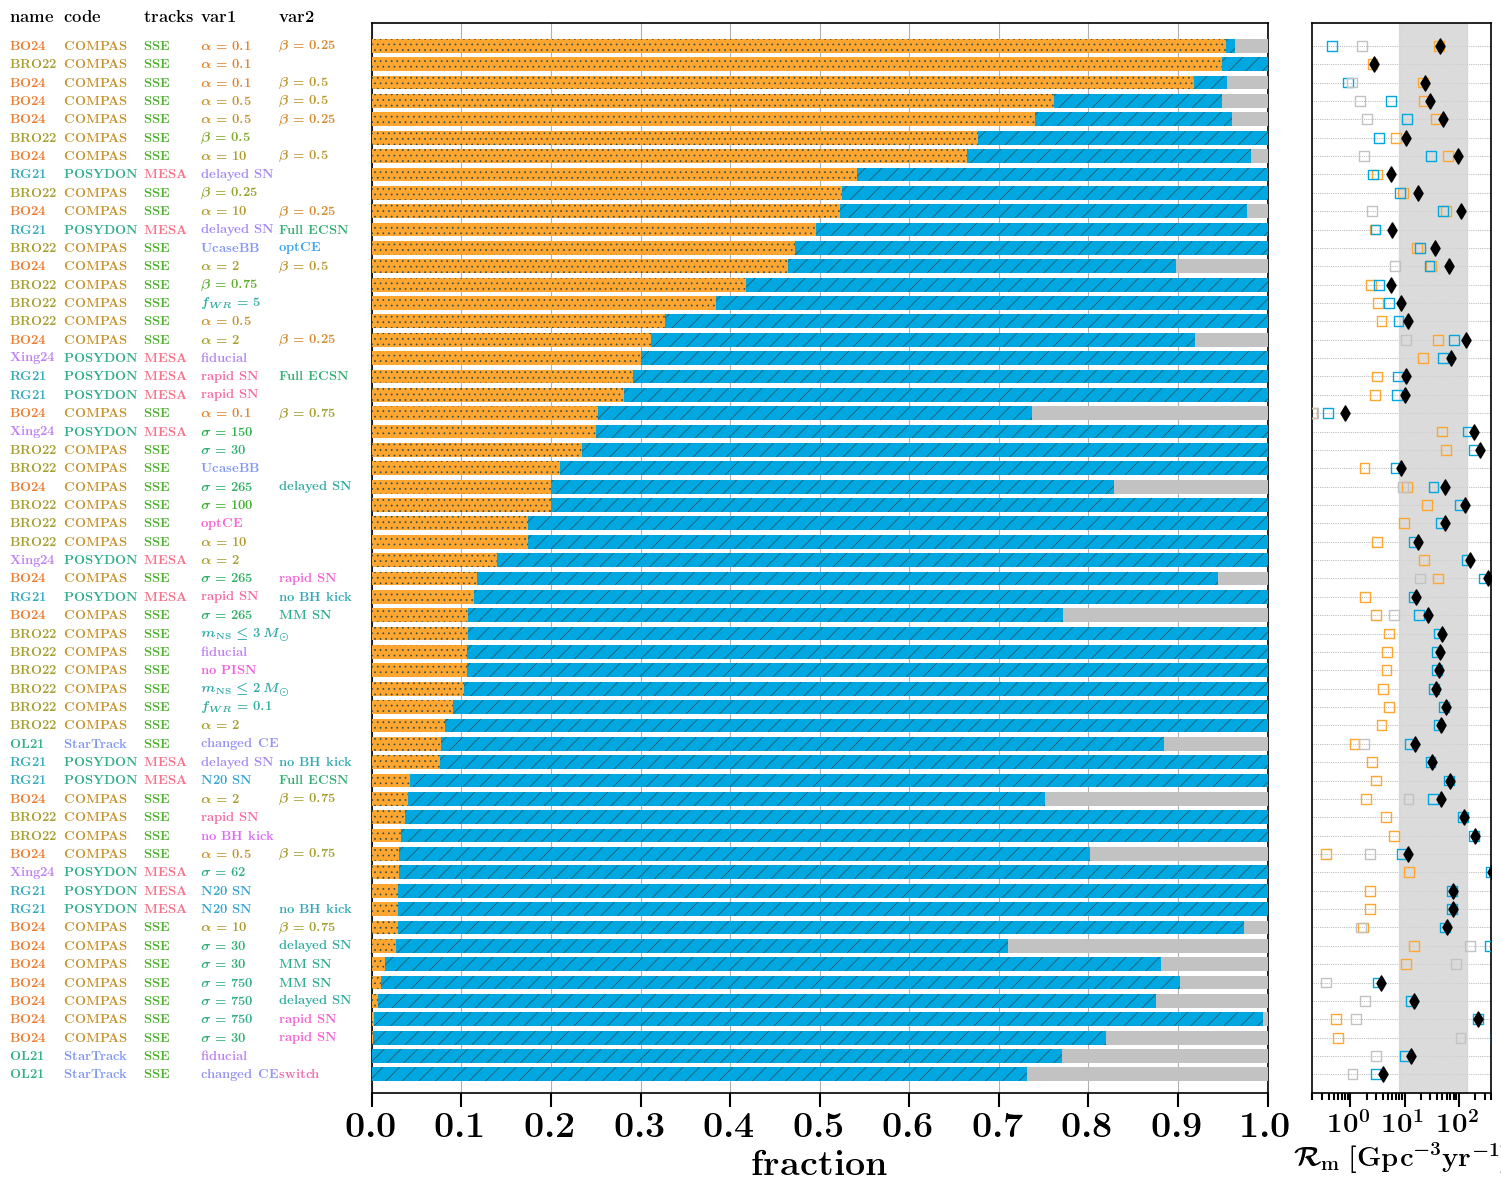

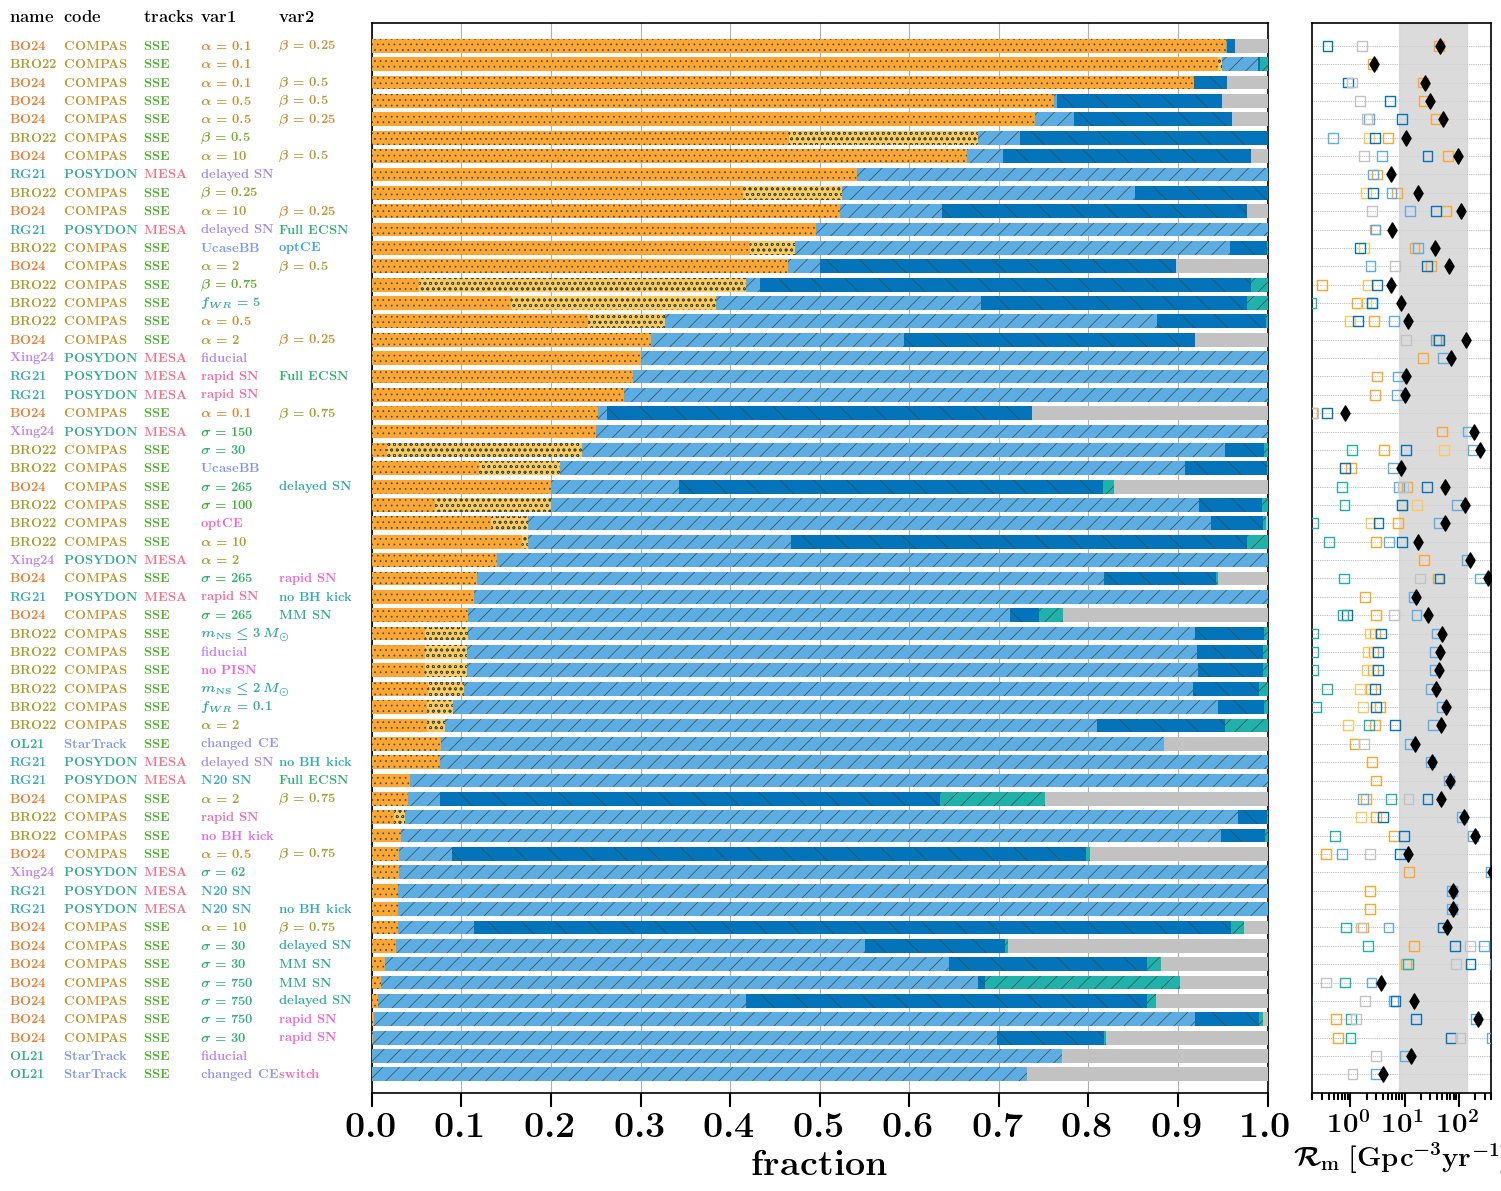

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [168]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-NS_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-NS_detailed.pdf"
    )


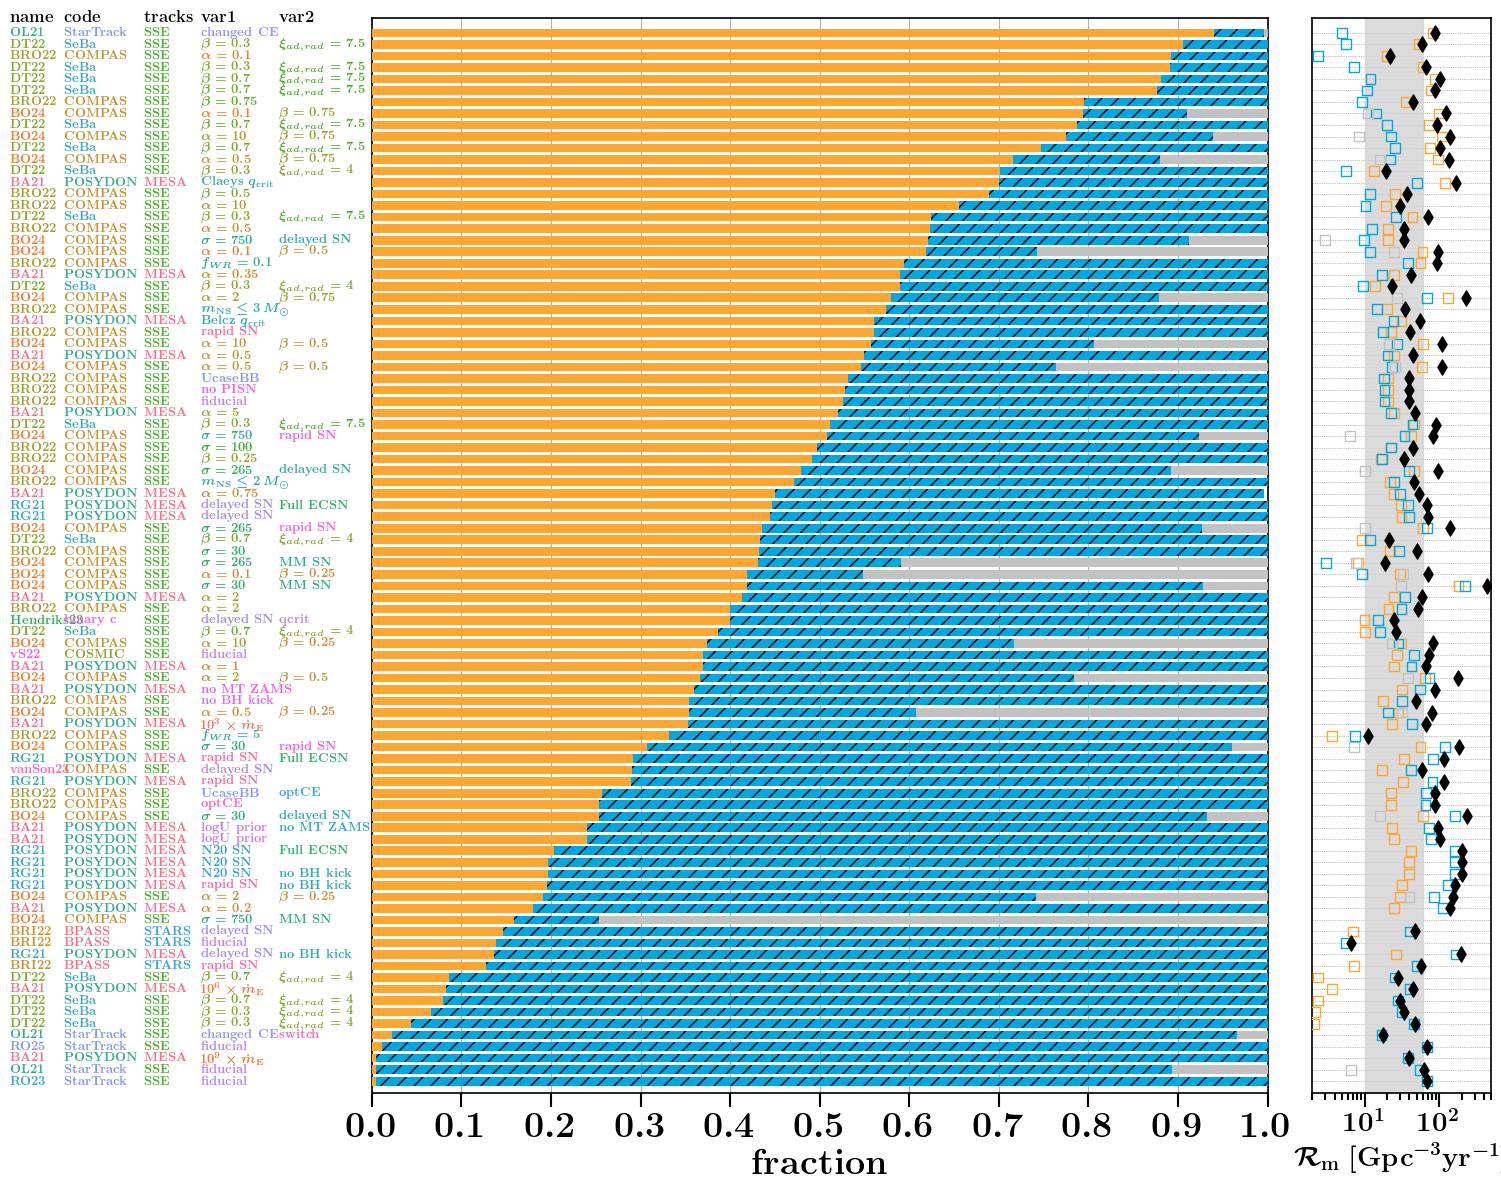

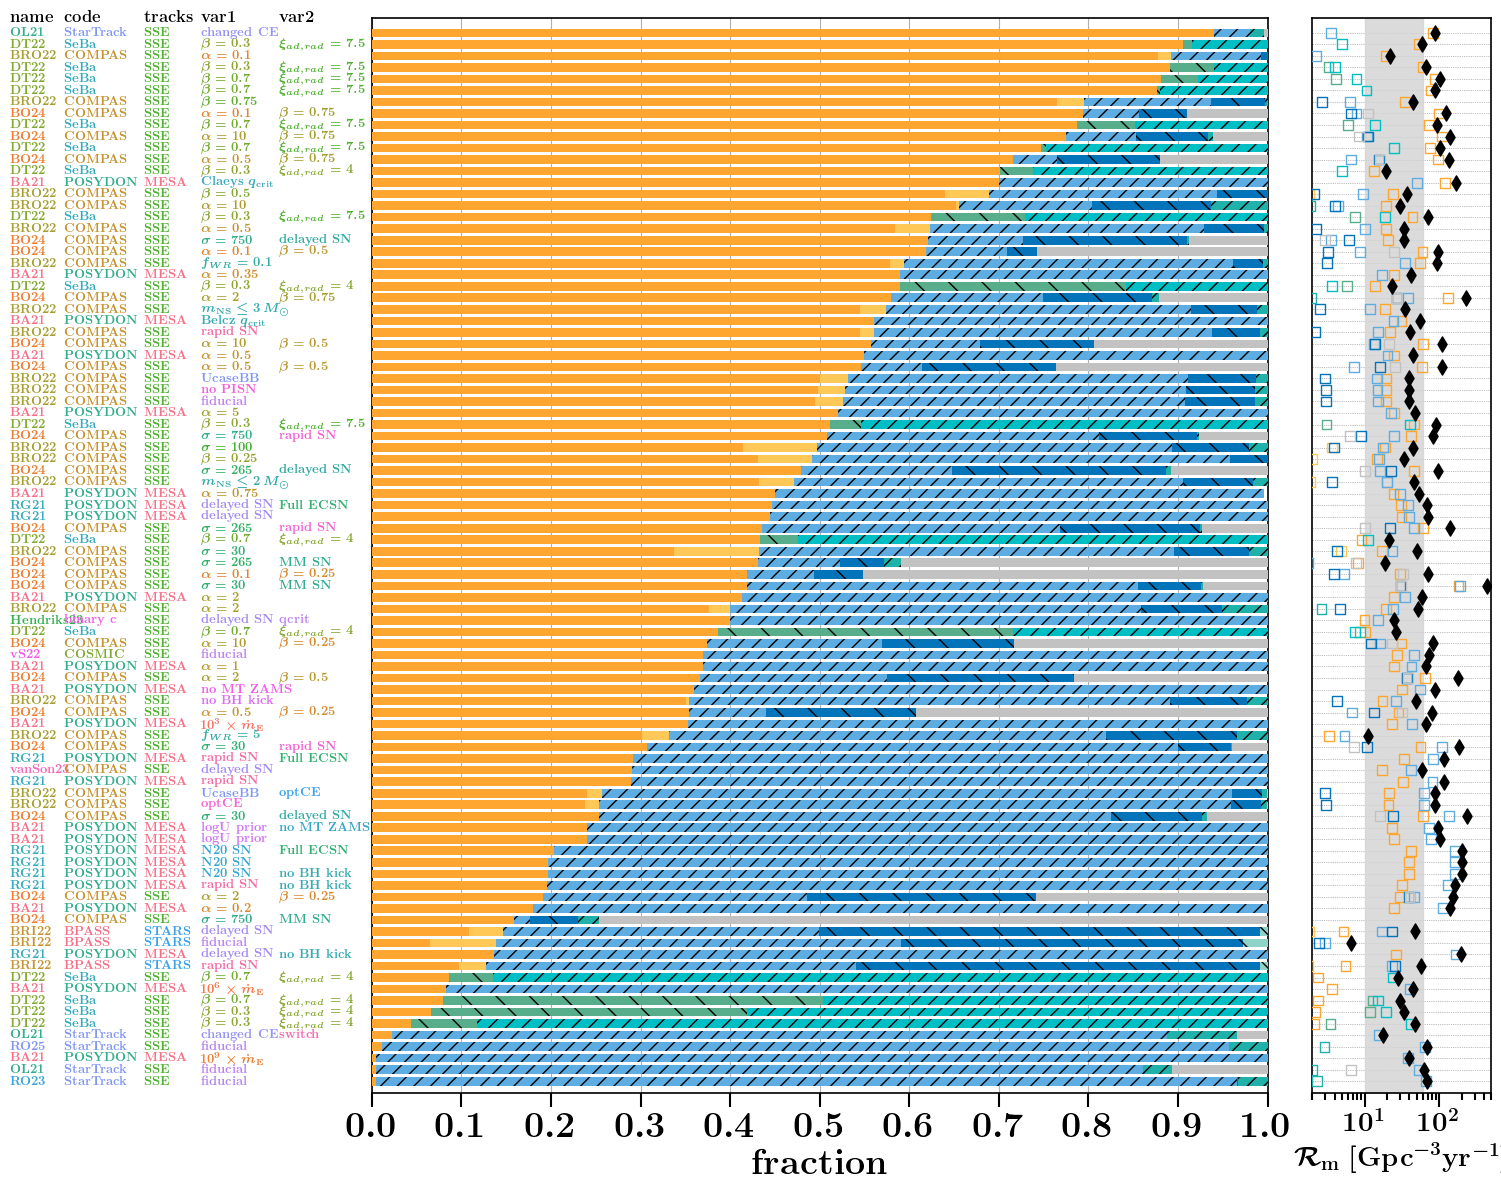

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [141]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-BH_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-NS_detailed.pdf"
    )


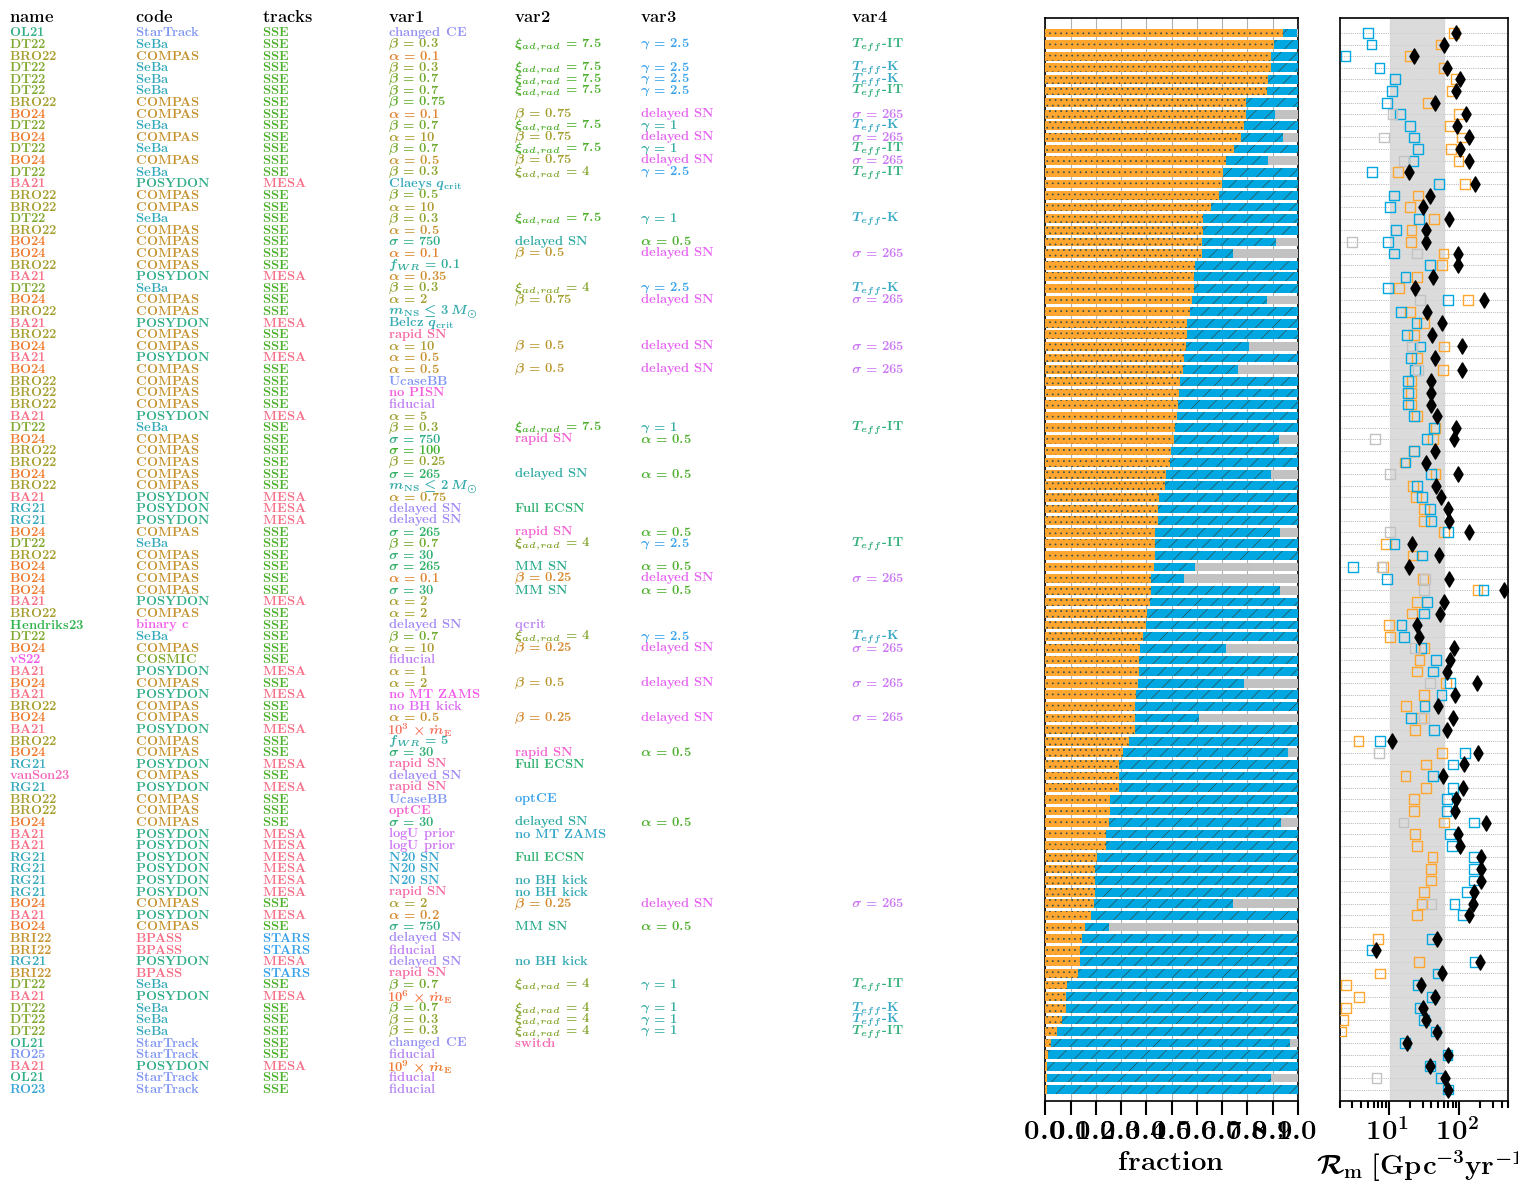

In [169]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-BH_simple.pdf",
    fig_formtype='emph_specs'
    )


# # plot detailed formation channels CE 
# plot_formation_channel_contributions(
#     path_to_file=path_to_file,
#     DCOlabel = 'BH-BH',
#     fc_key = "CE_detailed" ,
#     sort_header = "fraction without common envelope",
#     save_path = "formation_channels_BH-NS_detailed.pdf"
#     )


